In [1]:
import torch
from torch import nn
import torch.nn.functional as F

import os, sys, argparse, time
import numpy as np
import imageio.v2 as imageio
import fsspec
import wandb

from sklearn import preprocessing                           # preprocessing
from sklearn.model_selection import StratifiedShuffleSplit  # cross-validation object with a merge of StratifiedKFold and ShuffleSplit --> can do `n_split=1` + stratified
from torchvision import transforms                          # data augmentation (per epoch)
from torch.utils.data import WeightedRandomSampler, Subset  # balance training data (https://docs.pytorch.org/docs/stable/data.html#torch.utils.data.WeightedRandomSampler)


labelmap = {
"Actin_disruptors": 0,
"Aurora_kinase_inhibitors": 1,
"Cholesterol-lowering": 2,
"DMSO": 3,
"DNA_damage": 4,
"DNA_replication": 5,
"Eg5_inhibitors": 6,
"Epithelial": 7,
"Kinase_inhibitors": 8,
"Microtubule_destabilizers": 9,
"Microtubule_stabilizers": 10,
"Protein_degradation": 11,
"Protein_synthesis": 12
}
NUM_CLASSES=len(labelmap)


In [2]:
args = argparse.Namespace(
    train_data_dir = '/net/dali/home/mscbio/til177/Github/cobb2060-2026s/project5_CNN_cellImg_classifier/data/train',
)
print(args.train_data_dir)

/net/dali/home/mscbio/til177/Github/cobb2060-2026s/project5_CNN_cellImg_classifier/data/train


## Check the data

In [3]:
class ImgDataset(torch.utils.data.Dataset):
    """
    Dataset for reading in images from a training directory
    - 3-channel: DNA/actin/tubulin (R/G/B)

    Additional operation to per sample:
    1. Apply min-max normalization to each sample, each channel
    2. Interpolation to reduce file size
    3. (Optional) Data augmentation

    """

    def __init__(self, train_data_dir, augment=False, img_size=512): #img_size as a hyperparam for downsampling (without maxpooling)
        self.augment = augment
        self.img_size = img_size
        # stored  image locations  in self.examples
        with fsspec.open_files(train_data_dir+'/TRAIN',mode='rt')[0] as f: #TRAIN file - kind of like metadata file
            self.examples = [] # list of (label, [red,green,blue files])
            for line in f:
                label, c1, c2, c3 = line.rstrip().split(' ')
                #create absolute paths for image files
                self.examples.append((labelmap[label], [ train_data_dir + '/' + c for c in (c1,c2,c3)]))
        # Define augmentation transformation method (same transform applied to all 3 channels)
        self.aug_transform = transforms.Compose([
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.5),
            transforms.RandomRotation(degrees=90), #always applies
        ])

    #### METHOD ####
    def open_image(self, path):
        '''Return img at path, caching downloaded images'''
        fname =  path.rsplit('/',1)[-1] # get the file name
        if path.startswith('gs://'):    # check for downloaded file
            if os.path.exists(fname):
                path = fname
        if path.startswith('gs://'):    # If still a GCS path (not cached yet), cache download
            with fsspec.open_files(path,mode='rb')[0] as img:
                out = open(fname,'wb')
                out.write(img.read())
                out.close()
                path = fname
        return  imageio.imread(open(path,'rb'))

    def __len__(self):
        return len(self.examples)
        
    def __getitem__(self, idx): #map style - selecting instance from the class
        label, fnames = self.examples[idx]
        imgs = [self.open_image(fname) for fname in fnames]
        
        # Stack 3 greyscale images → (3, H, W) float32
        arr    = np.array(imgs, dtype=np.float32)    # (3, 512, 512)
        tensor = torch.from_numpy(arr)               # (3, 512, 512)
        
        #### Min-max normalization: each channel independently to [0, 1] ####
        for c in range(tensor.shape[0]):
            cmin, cmax = tensor[c].min(), tensor[c].max()
            if cmax > cmin:
                tensor[c] = (tensor[c] - cmin) / (cmax - cmin)

        #### Use bilinear interpolation to reduce input img size ####
        tensor = F.interpolate(
            tensor.unsqueeze(0), #F.interpolate needs 4D data
            size=(self.img_size, self.img_size),
            mode="bilinear", align_corners=False
        ).squeeze(0)
        
        #### Data augmentation (training split only) ####
        if self.augment:
            #NOTE: use shared seed to ensure same transformation across the channels
            seed = torch.randint(0, 2**32, (1,)).item() #return a python int
            channels = []
            for c in range(tensor.shape[0]):
                torch.manual_seed(seed)
                channels.append(
                    self.aug_transform(tensor[c].unsqueeze(0)).squeeze(0)
                )
            tensor = torch.stack(channels, dim=0) #rebuild

        #perhaps consider applying an image transform
        return {"img": tensor, "label": label}
    

    def visualize(self, idx, channel_names=["Actin", "DNA", "Tubulin"]): #from the train/TRAIN file
        """
        Plot a single sample: composite + individual channels.

        usage: dataset.visualize(0)
        """
        import matplotlib.pyplot as plt
        
        sample = self[idx]  # calls __getitem__
        tensor = sample['img']
        label = sample['label']
        
        #get its label string
        reverse_labelmap = {v: k for k, v in labelmap.items()}
        
        fig, axes = plt.subplots(1, 4, figsize=(16, 4))
        axes[0].imshow(tensor.permute(1, 2, 0).numpy()) #get matplotlilb format (H,W,C)
        axes[0].set_title(f"{reverse_labelmap[label]} (composite)")
        
        for c in range(3):
            axes[c+1].imshow(tensor[c].numpy(), cmap='gray')
            axes[c+1].set_title(channel_names[c])
        
        for ax in axes:
            ax.axis('off')
        plt.tight_layout()
        plt.show()

    def get_labels(self):
        """Return list of integer labels for all examples (used for stratified split)."""
        return [ex[0] for ex in self.examples]
    
    # Compute per-sample sampling weights (WeightedRandomSampler over training set -> inverse N)
    def get_class_weights_for_trainIdx(self, train_idx): #indices from stratified split
        
        labels = [self.examples[i][0] for i in train_idx]
        class_counts = np.bincount(
            labels, minlength=NUM_CLASSES # ensure the fixed length of output
        ).astype(float)
        class_weights = 1.0 / np.maximum(class_counts, 1) #prevent 0 division

        # assign to per-sample
        sample_weights = [class_weights[l] for l in labels]

        return torch.DoubleTensor(sample_weights)
    

# -------- Stratified train/val split --------
def make_StratifiedShuffleSplit(dataset, val_frac=0.2, random_seed=42):
    """
    Split dataset indices into train and val sets (allow for 1 split given high computation cost), preserving class proportions.
    Returns:
        train_indices, val_indices (lists of integer)
    """
    labels = dataset.get_labels()
    splitter = StratifiedShuffleSplit(
        n_splits=1, test_size=val_frac, random_state=random_seed
    )
    train_idx, val_idx = next(
        splitter.split(
            np.zeros(len(labels)), # place holder for correct dim
            labels
        )
    ) #grad the single split -> np.array

    return train_idx.tolist(), val_idx.tolist()

In [4]:
full_data = ImgDataset(train_data_dir=args.train_data_dir)
print(full_data.examples[0])

label, fnames = full_data.examples[0]
'/net/dali/home/mscbio/til177/Github/cobb2060-2026s/project5_CNN_cellImg_classifier/data/train/a_0.tif'.rsplit('/',1)[-1]

(0, ['/net/dali/home/mscbio/til177/Github/cobb2060-2026s/project5_CNN_cellImg_classifier/data/train/a_0.tif', '/net/dali/home/mscbio/til177/Github/cobb2060-2026s/project5_CNN_cellImg_classifier/data/train/d_0.tif', '/net/dali/home/mscbio/til177/Github/cobb2060-2026s/project5_CNN_cellImg_classifier/data/train/t_0.tif'])


'a_0.tif'

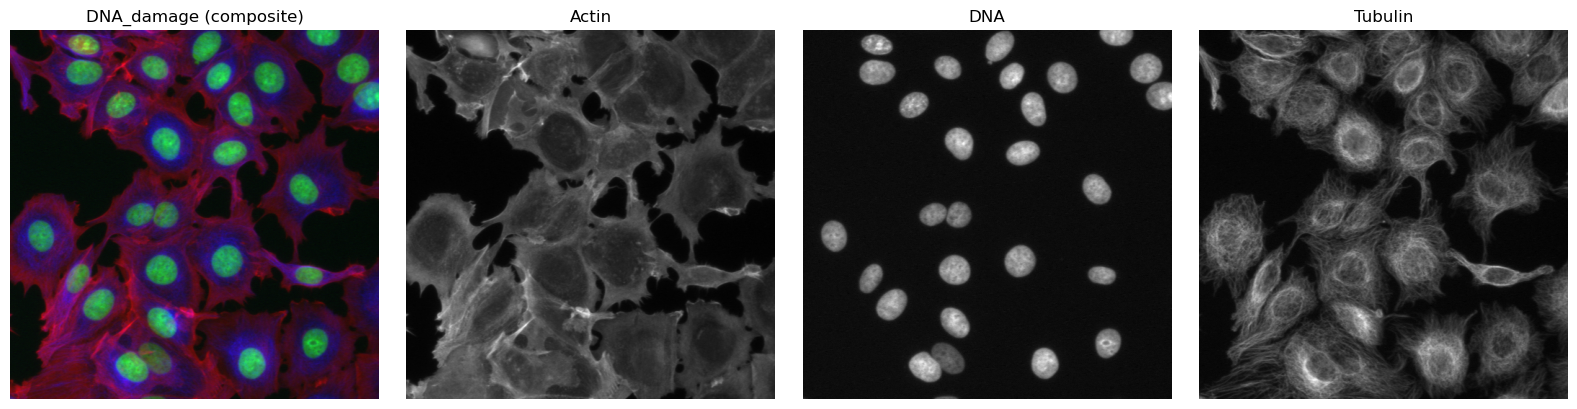

In [5]:
dataset = ImgDataset(args.train_data_dir, augment=False, img_size=512)

# #Grab one sample
# sample = dataset[0]       # returns a dict
# tensor = sample['img']    # not tuple unpacking
# label = sample['label']

# # Reverse lookup label name
# reverse_labelmap = {v: k for k, v in labelmap.items()}

# import matplotlib.pyplot as plt
# fig, axes = plt.subplots(1, 4, figsize=(16, 4))
# # RGB composite
# axes[0].imshow(tensor.permute(1, 2, 0).numpy()) #permute is matplot lib format
# axes[0].set_title(f"{reverse_labelmap[label]} (composite)")

# # Individual channels
# channel_names = ["DNA", "Actin", "Tubulin"]
# for c in range(3):
#     axes[c+1].imshow(tensor[c].numpy(), cmap='gray')
#     axes[c+1].set_title(channel_names[c])

# for ax in axes:
#     ax.axis('off')
# plt.tight_layout()
# plt.show()

dataset.visualize(1221)

## Check the CNN

In [6]:
class ConvBlock(nn.Module):  # inherits from nn.Module
    def __init__(self, in_ch, out_ch):
        """
        usually, out_channel doubled in deeper layers (to compensate spatial dimension skrinkage)
        3  -> 32
        32 -> 64...

        Thus, mathematically, if    base_ch = 32
                              then  block N with out_ch = base_ch * 2^(n_block-1) 
        """
        super().__init__()   # calls nn.Module constructor
        
        self.block = nn.Sequential( # nn.Sequential requires nn.Module objects! 
                                    # (although maxpool and relu do not have parameters to learn)
            # Default params  except padding
            nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=1, padding=1, #(n+2p-f)/s+1 -> same size feature map
                     dilation=1, groups=1, bias=True),
            nn.BatchNorm2d(num_features=out_ch), #channel;   NOTE:to prevent ReLU being killed due to the skewed value, we do BN here
            nn.ReLU(inplace=True), # less mem
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        )
        
    def forward(self, x):
        return self.block(x)


class MyCNN(nn.Module):
    """
    Architecture:
        N x ConvBlock (Con -> BN -> ReLU -> MaxPool)
        -> Global Average Pooling                                                ##NOTE: To be able to configurable, instead of using torch.flatten() with fixed val
        -> Linear( base_ch * 2^(n_conv_blocks-1), fc_size ) -> ReLU -> Dropout   ##NOTE: Combine nonlinear features -> dropout (this is where overfitting mainly happens)
        -> Linear( fc_size, 13 )                                                 ##NOTE: Fully connected layer2 for logits (later softmax in loss)
    Output: (softmax_probs, logits)
    """
    def __init__(self, n_conv_blocks=4, 
                 base_ch=32,  # first out_ch
                 fc_size=256, # fully connected layer size (hyperparam)
                 dropout_p=0.5, img_size=512):
        
        super(MyCNN, self).__init__()

        # [configurable] first compute the list of channels for each block
        ls_channels = [3] + [base_ch * (2 ** i) for i in range(n_conv_blocks)]

        #  Define model
        ls_ConvBlock = [
            ConvBlock(ls_channels[i], ls_channels[i+1])
            for i in range(n_conv_blocks)
        ]
        ls_fc = [
            nn.Flatten(), #into a tensor
            nn.Linear(in_features=ls_channels[-1], out_features=fc_size),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_p),
            nn.Linear(fc_size, NUM_CLASSES)
        ]

        self.conv = nn.Sequential(*ls_ConvBlock)
        self.gap  = nn.AdaptiveAvgPool2d(output_size=1) #make 1 dimension before flatten
        self.fc   = nn.Sequential(*ls_fc)

    def forward(self, x):
        # Apply model
        x = self.conv(x)
        x = self.gap(x)
        logits = self.fc(x)

        # For evaluation:   we want a softmax - you must return this as the first element of a tuple.  
        # For training:     in order to use the numerically more stable cross_entropy loss, we will also return the un-softmaxed values
        return F.softmax(logits, dim=1), logits


In [7]:
from torchinfo import summary

model = MyCNN(n_conv_blocks=4, base_ch=32, fc_size=256)
summary(model, input_size=(1, 3, 512, 512))  # (batch, channels, H, W)

Layer (type:depth-idx)                   Output Shape              Param #
MyCNN                                    [1, 13]                   --
├─Sequential: 1-1                        [1, 256, 32, 32]          --
│    └─ConvBlock: 2-1                    [1, 32, 256, 256]         --
│    │    └─Sequential: 3-1              [1, 32, 256, 256]         960
│    └─ConvBlock: 2-2                    [1, 64, 128, 128]         --
│    │    └─Sequential: 3-2              [1, 64, 128, 128]         18,624
│    └─ConvBlock: 2-3                    [1, 128, 64, 64]          --
│    │    └─Sequential: 3-3              [1, 128, 64, 64]          74,112
│    └─ConvBlock: 2-4                    [1, 256, 32, 32]          --
│    │    └─Sequential: 3-4              [1, 256, 32, 32]          295,680
├─AdaptiveAvgPool2d: 1-2                 [1, 256, 1, 1]            --
├─Sequential: 1-3                        [1, 13]                   --
│    └─Flatten: 2-5                      [1, 256]                  --
│

## Test run the training process

In [9]:
import torch
from torch import nn
import torch.nn.functional as F

import os, sys, argparse, time
import numpy as np
import imageio.v2 as imageio
import fsspec
import wandb

from sklearn.model_selection import StratifiedShuffleSplit  # cross-validation object with a merge of StratifiedKFold and ShuffleSplit --> can do `n_split=1` + stratified
from torchvision import transforms                          # data augmentation (per epoch)
from torch.utils.data import WeightedRandomSampler, Subset  # balance training data (https://docs.pytorch.org/docs/stable/data.html#torch.utils.data.WeightedRandomSampler)

"""
Ultimate Training Scheme (Claude generated)

Full Dataset
    │
    ▼
StratifiedShuffleSplit  →  ensures test set has all classes proportionally
    │
    ├── Train set (imbalanced, reflects original distribution)
    │       │
    │       ▼
    │   WeightedRandomSampler  →  balances batches during training
    │
    └── Test set (imbalanced, reflects original distribution)
            │
            ▼
        Evaluate as-is (you WANT the test set to reflect real distribution)
"""


# -------- Define label mapping --------
labelmap = {
"Actin_disruptors": 0,
"Aurora_kinase_inhibitors": 1,
"Cholesterol-lowering": 2,
"DMSO": 3,
"DNA_damage": 4,
"DNA_replication": 5,
"Eg5_inhibitors": 6,
"Epithelial": 7,
"Kinase_inhibitors": 8,
"Microtubule_destabilizers": 9,
"Microtubule_stabilizers": 10,
"Protein_degradation": 11,
"Protein_synthesis": 12
}
NUM_CLASSES=len(labelmap)


# -------- Process data -------- 
class ImgDataset(torch.utils.data.Dataset):
    """
    Dataset for reading in images from a training directory
    - 3-channel: DNA/actin/tubulin (R/G/B)

    Additional operation to per sample:
    1. Apply min-max normalization to each sample, each channel
    2. Interpolation to reduce file size
    3. (Optional) Data augmentation

    """

    def __init__(self, train_data_dir, augment=False, img_size=512): #img_size as a hyperparam for downsampling (without maxpooling)
        self.augment = augment
        self.img_size = img_size
        # stored  image locations  in self.examples
        with fsspec.open_files(train_data_dir+'/TRAIN',mode='rt')[0] as f: #TRAIN file - kind of like metadata file
            self.examples = [] # list of (label, [red,green,blue files])
            for line in f:
                label, c1, c2, c3 = line.rstrip().split(' ')
                #create absolute paths for image files
                self.examples.append((labelmap[label], [ train_data_dir + '/' + c for c in (c1,c2,c3)]))
        # Define augmentation transformation method (same transform applied to all 3 channels)
        self.aug_transform = transforms.Compose([
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.5),
            transforms.RandomRotation(degrees=90), #always applies
        ])

    #### METHOD ####
    def open_image(self, path):
        '''Return img at path, caching downloaded images'''
        fname =  path.rsplit('/',1)[-1] # get the file name
        if path.startswith('gs://'):    # check for downloaded file
            if os.path.exists(fname):
                path = fname
        if path.startswith('gs://'):    # If still a GCS path (not cached yet), cache download
            with fsspec.open_files(path,mode='rb')[0] as img:
                out = open(fname,'wb')
                out.write(img.read())
                out.close()
                path = fname
        return  imageio.imread(open(path,'rb'))

    def __len__(self):
        return len(self.examples)
        
    def __getitem__(self, idx): #map style - selecting instance from the class
        label, fnames = self.examples[idx]
        imgs = [self.open_image(fname) for fname in fnames]
        
        # Stack 3 greyscale images → (3, H, W) float32
        arr    = np.array(imgs, dtype=np.float32)    # (3, 512, 512)
        tensor = torch.from_numpy(arr)               # (3, 512, 512)
        
        #### Min-max normalization: each channel independently to [0, 1] ####
        for c in range(tensor.shape[0]):
            cmin, cmax = tensor[c].min(), tensor[c].max()
            if cmax > cmin:
                tensor[c] = (tensor[c] - cmin) / (cmax - cmin)

        #### Use bilinear interpolation to reduce input img size ####
        tensor = F.interpolate(
            tensor.unsqueeze(0), #F.interpolate needs 4D data
            size=(self.img_size, self.img_size),
            mode="bilinear", align_corners=False
        ).squeeze(0)
        
        #### Data augmentation (training split only) ####
        if self.augment:
            #NOTE: use shared seed to ensure same transformation across the channels
            seed = torch.randint(0, 2**32, (1,)).item() #return a python int
            channels = []
            for c in range(tensor.shape[0]):
                torch.manual_seed(seed)
                channels.append(
                    self.aug_transform(tensor[c].unsqueeze(0)).squeeze(0)
                )
            tensor = torch.stack(channels, dim=0) #rebuild

        #perhaps consider applying an image transform
        return {"img": tensor, "label": label}
    

    def visualize(self, idx, channel_names=["Actin", "DNA", "Tubulin"]): #from the train/TRAIN file
        """
        Plot a single sample: composite + individual channels.

        usage: dataset.visualize(0)
        """
        import matplotlib.pyplot as plt
        
        sample = self[idx]  # calls __getitem__
        tensor = sample['img']
        label = sample['label']
        
        #get its label string
        reverse_labelmap = {v: k for k, v in labelmap.items()}
        
        fig, axes = plt.subplots(1, 4, figsize=(16, 4))
        axes[0].imshow(tensor.permute(1, 2, 0).numpy()) #get matplotlilb format (H,W,C)
        axes[0].set_title(f"{reverse_labelmap[label]} (composite)")
        
        for c in range(3):
            axes[c+1].imshow(tensor[c].numpy(), cmap='gray')
            axes[c+1].set_title(channel_names[c])
        
        for ax in axes:
            ax.axis('off')
        plt.tight_layout()
        plt.show()

    def get_labels(self):
        """Return list of integer labels for all examples (used for stratified split)."""
        return [ex[0] for ex in self.examples]
    
    # Compute per-sample sampling weights (WeightedRandomSampler over training set -> inverse N)
    def get_class_weights_for_trainIdx(self, train_idx): #indices from stratified split
        
        labels = [self.examples[i][0] for i in train_idx]
        class_counts = np.bincount(
            labels, minlength=NUM_CLASSES # ensure the fixed length of output
        ).astype(float)
        class_weights = 1.0 / np.maximum(class_counts, 1) #prevent 0 division

        # assign to per-sample
        sample_weights = [class_weights[l] for l in labels]

        return torch.DoubleTensor(sample_weights)
    

# -------- Stratified train/val split --------
def make_StratifiedShuffleSplit(dataset, val_frac=0.2, random_seed=42):
    """
    Split dataset indices into train and val sets (allow for 1 split given high computation cost), preserving class proportions.
    Returns:
        train_indices, val_indices (lists of integer)
    """
    labels = dataset.get_labels()
    splitter = StratifiedShuffleSplit(
        n_splits=1, test_size=val_frac, random_state=random_seed
    )
    train_idx, val_idx = next(
        splitter.split(
            np.zeros(len(labels)), # place holder for correct dim
            labels
        )
    ) #grab the single split -> np.array

    return train_idx.tolist(), val_idx.tolist()


# ------------------------------------------------------------
# Define CNN
# ------------------------------------------------------------

# We need multiple same sequence of layers (conv -> bn -> relu -> maxpool)  -> defome a conv block with channel info

class ConvBlock(nn.Module):  # inherits from nn.Module
    def __init__(self, in_ch, out_ch):
        """
        usually, out_channel doubled in deeper layers (to compensate spatial dimension skrinkage)
        3  -> 32
        32 -> 64...

        Thus, mathematically, if    base_ch = 32
                              then  block N with out_ch = base_ch * 2^(n_block-1) 
        """
        super().__init__()   # calls nn.Module constructor
        
        self.block = nn.Sequential( # nn.Sequential requires nn.Module objects! 
                                    # (although maxpool and relu do not have parameters to learn)
            # Default params  except padding
            nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=1, padding=1, #(n+2p-f)/s+1 -> same size feature map
                     dilation=1, groups=1, bias=True),
            nn.BatchNorm2d(num_features=out_ch), #channel;   NOTE:to prevent ReLU being killed due to the skewed value, we do BN here
            nn.ReLU(inplace=True), # less mem
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        )
        
    def forward(self, x):
        return self.block(x)


class MyCNN(nn.Module):
    """
    Architecture:
        N x ConvBlock (Con -> BN -> ReLU -> MaxPool)
        -> Global Average Pooling                                                ##NOTE: To be able to configurable, instead of using torch.flatten() with fixed val
        -> Linear( base_ch * 2^(n_conv_blocks-1), fc_size ) -> ReLU -> Dropout   ##NOTE: Combine nonlinear features -> dropout (this is where overfitting mainly happens)
        -> Linear( fc_size, 13 )                                                 ##NOTE: Fully connected layer2 for logits (later softmax in loss)
    Output: (softmax_probs, logits)
    """
    def __init__(self, n_conv_blocks=4, 
                 base_ch=32,  # first out_ch
                 fc_size=256, # fully connected layer size (hyperparam)
                 dropout_p=0.5, img_size=512):
        
        super(MyCNN, self).__init__()

        # [configurable] first compute the list of channels for each block
        ls_channels = [3] + [base_ch * (2 ** i) for i in range(n_conv_blocks)]

        #  Define model
        ls_ConvBlock = [
            ConvBlock(ls_channels[i], ls_channels[i+1])
            for i in range(n_conv_blocks)
        ]
        ls_fc = [
            nn.Flatten(), #into a tensor
            nn.Linear(in_features=ls_channels[-1], out_features=fc_size),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_p),
            nn.Linear(fc_size, NUM_CLASSES)
        ]

        self.conv = nn.Sequential(*ls_ConvBlock)
        self.gap  = nn.AdaptiveAvgPool2d(output_size=1) #make 1 dimension before flatten
        self.fc   = nn.Sequential(*ls_fc)

    def forward(self, x):
        # Apply model
        x = self.conv(x)
        x = self.gap(x)
        logits = self.fc(x)

        # For evaluation:   we want a softmax only - you must return this as the first element of a tuple.  
        # For training:     in order to use the numerically more stable cross_entropy loss, we will also return the un-softmaxed values
        return F.softmax(logits, dim=1), logits


"""
from torchinfo import summary

model = MyCNN(n_conv_blocks=4, base_ch=32, fc_size=256)
summary(model, input_size=(1, 3, 512, 512))  # (batch, channels, H, W)

==========================================================================================
Layer (type:depth-idx)                   Output Shape              Param #
==========================================================================================
MyCNN                                    [1, 13]                   --
├─Sequential: 1-1                        [1, 256, 32, 32]          --
│    └─ConvBlock: 2-1                    [1, 32, 256, 256]         --
│    │    └─Sequential: 3-1              [1, 32, 256, 256]         960
│    └─ConvBlock: 2-2                    [1, 64, 128, 128]         --
│    │    └─Sequential: 3-2              [1, 64, 128, 128]         18,624
│    └─ConvBlock: 2-3                    [1, 128, 64, 64]          --
│    │    └─Sequential: 3-3              [1, 128, 64, 64]          74,112
│    └─ConvBlock: 2-4                    [1, 256, 32, 32]          --
│    │    └─Sequential: 3-4              [1, 256, 32, 32]          295,680
├─AdaptiveAvgPool2d: 1-2                 [1, 256, 1, 1]            --
├─Sequential: 1-3                        [1, 13]                   --
│    └─Flatten: 2-5                      [1, 256]                  --
│    └─Linear: 2-6                       [1, 256]                  65,792
│    └─ReLU: 2-7                         [1, 256]                  --
│    └─Dropout: 2-8                      [1, 256]                  --
│    └─Linear: 2-9                       [1, 13]                   3,341
==========================================================================================
Total params: 458,509
Trainable params: 458,509
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 3.87
==========================================================================================
Input size (MB): 3.15
Forward/backward pass size (MB): 251.66
Params size (MB): 1.83
Estimated Total Size (MB): 256.64
==========================================================================================
"""


# ------------------------------------------------------------
# Add ExportModel wrapper so that the eval.py can have preprocessing
# ------------------------------------------------------------
class ExportModel(nn.Module):
    """Wrap preprocessing into the model for eval.py compatibility."""
    def __init__(self, model, img_size=512):
        super().__init__()
        self.model = model
        self.img_size = img_size

    def forward(self, x):
        # Min-max normalize per sample, per channel — fully vectorized
        cmin = x.amin(dim=(-2, -1), keepdim=True)  # (B, C, 1, 1)
        cmax = x.amax(dim=(-2, -1), keepdim=True)  # (B, C, 1, 1)
        denom = torch.clamp(cmax - cmin, min=1e-8)
        x = (x - cmin) / denom
        
        # Resize
        x = F.interpolate(x, size=(self.img_size, self.img_size),
                          mode="bilinear", align_corners=False)
        return self.model(x)



# -------- Validation --------
@torch.no_grad()
def evaluate(model, dataloader, loss_object, device):
    """
    Run one pass over the validation set 
    Returns: mean (loss, accuracy)
    """
    model.eval() #eval mode

    total_loss, correct, total = 0.0, 0, 0
    for batch in dataloader:
        imgs   = batch["img"].to(device)
        labels = batch["label"].to(device)

        _, logits = model(imgs) #validation still need loss
        
        loss  = loss_object(logits, labels)
        preds = logits.argmax(dim=1)
        bs    = labels.size(0)

        total_loss += loss.item() * bs
        correct    += (preds == labels).sum().item()
        total      += bs

    model.train() #back to train for next epoch

    return total_loss/total, correct/total


# ------------------------------------------------------------
# Training loop (without wandb)
# ------------------------------------------------------------
def run_training(args):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device: {device}")

    #### Prep data ####
    # Load the full dataset
    full_dataset = ImgDataset(args.train_data_dir, augment=False, img_size=args.img_size)

    # Stratified train-test 80/20 split
    train_idx, val_idx = make_StratifiedShuffleSplit(full_dataset, val_frac=0.2, random_seed=42)
    print(f"Split: {len(train_idx)} train / {len(val_idx)} val")
    
    # Turn on the augmentation and ONLY select train data
    train_dataset = ImgDataset(args.train_data_dir, augment=True, img_size=args.img_size)
    train_subset = Subset(train_dataset, train_idx)

    # Eval data (validation)
    eval_subset = Subset(full_dataset, val_idx)

    #### Setup DataLoader ####
    sample_weights = full_dataset.get_class_weights_for_trainIdx(train_idx)
    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(train_idx),
        replacement=True # key to allow oversampling
    )

    train_loader = torch.utils.data.DataLoader(
        train_subset, batch_size=args.batch_size, sampler=sampler,
        num_workers=4, pin_memory=True #allow prefetching in parellel in cpu
    )
    eval_loader = torch.utils.data.DataLoader(
        eval_subset, batch_size=args.batch_size, shuffle=False, # no need to bother
        num_workers=4, pin_memory=True
    )
    
    #### Create an instance of the model ####
    model = MyCNN(n_conv_blocks=args.n_conv_blocks, base_ch=args.base_ch, fc_size=args.fc_size,
                  dropout_p=args.dropout_p, img_size=args.img_size).to(device)
    
    #### Loss, Optimizer, Scheduler ####
    loss_object = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=args.lr, weight_decay=args.weight_decay) #regularization in loss
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=args.max_epochs)
    
    #### Training loop ####
    best_val_acc = 0.0
    losses = []
    
    for epoch in range(args.max_epochs):
        
        model.train() #training mode
        epoch_loss, correct, total = 0.0, 0, 0
        start = time.time()

        for i, batch in enumerate(train_loader): #iterator over batches
            imgs   = batch["img"].to(device)
            labels = batch["label"].to(device)

            optimizer.zero_grad() #IMPORTANT! reset gradient

            ## 1. forward pass
            _, logits = model(imgs) #softmax in eval is omitted

            ## 2. calculate loss (mean loss here)
            loss = loss_object(logits, labels)

            ## 3. backward prop
            loss.backward()

            ## 4. optimization, update param
            optimizer.step()

            ## calculate the summary stats
            losses.append(loss.item())
            epoch_loss += loss.item() * labels.size(0) #total loss per batch
            correct    += (logits.argmax(dim=1) == labels).sum().item()
            total      += labels.size(0)

            ## Write the summaries and print an overview fairly often.
            if i % 50 == 0: # total ~577 batches
                print('Epoch %d Iteration %d: loss = %f' % (epoch, i, losses[-1]))
                sys.stdout.flush()

        # Adjust learning rate AFTER the epoch
        scheduler.step()

        train_acc_perEpoch  = correct / total
        train_loss_perEpoch = epoch_loss / total

        val_loss_perEpoch, val_acc_perEpoch = evaluate(model, eval_loader, loss_object, device)
        if val_acc_perEpoch > best_val_acc:
            best_val_acc = val_acc_perEpoch

            # export_model = ExportModel(model, img_size=args.img_size).to(device)
            
            # # Export the model so that it can be loaded and used later for predictions.
            # #   For maximum compatibility export a trace of an application of the model
            # #   https://stackoverflow.com/questions/59287728/saving-pytorch-model-with-no-access-to-model-class-code  
            # testbatch = next(iter(eval_loader))
            # with torch.no_grad():
            #     export_model.eval()
            #     traced = torch.jit.trace(export_model, testbatch['img'].to(device)) #without need to reload the original class definition
            # torch.jit.save(traced, args.out+".best.pt")
            # model.train()
            
            # print(f"New best model saved (val_acc={best_val_acc:.4f})")

        print(f"Epoch {epoch}   train acc={train_acc_perEpoch:.4f}, loss={train_loss_perEpoch:.4f}")
        print(f"Epoch {epoch}   val   acc={val_acc_perEpoch:.4f}, loss={val_loss_perEpoch:.4f}")
        print("Epoch time:",time.time()-start)
        sys.stdout.flush()

        start = time.time()


    print(f"Best val acc: {best_val_acc:.4f}")

In [10]:
args = argparse.Namespace(
    train_data_dir = '/net/dali/home/mscbio/til177/Github/cobb2060-2026s/project5_CNN_cellImg_classifier/data/train',
    max_epochs = 20, img_size = 128, 
    batch_size=20, lr = 1e-3, weight_decay=1e-4, n_conv_blocks = 4, base_ch=32,
    fc_size=256, dropout_p=0.5, 
)
run_training(args)

Device: cuda
Split: 11544 train / 2886 val
Epoch 0 Iteration 0: loss = 2.599111
Epoch 0 Iteration 50: loss = 2.284501
Epoch 0 Iteration 100: loss = 1.995297
Epoch 0 Iteration 150: loss = 1.845489
Epoch 0 Iteration 200: loss = 1.458741
Epoch 0 Iteration 250: loss = 2.278038
Epoch 0 Iteration 300: loss = 1.555320
Epoch 0 Iteration 350: loss = 1.547538
Epoch 0 Iteration 400: loss = 1.228853
Epoch 0 Iteration 450: loss = 1.506361
Epoch 0 Iteration 500: loss = 1.273888
Epoch 0 Iteration 550: loss = 1.131471
Epoch 0   train acc=0.3913, loss=1.7284
Epoch 0   val   acc=0.4439, loss=1.7016
Epoch time: 191.1870255470276
Epoch 1 Iteration 0: loss = 1.275095
Epoch 1 Iteration 50: loss = 1.394989
Epoch 1 Iteration 100: loss = 1.410684
Epoch 1 Iteration 150: loss = 1.045471
Epoch 1 Iteration 200: loss = 1.217864
Epoch 1 Iteration 250: loss = 1.755514
Epoch 1 Iteration 300: loss = 1.062590
Epoch 1 Iteration 350: loss = 0.861298
Epoch 1 Iteration 400: loss = 0.951076
Epoch 1 Iteration 450: loss = 0.80